In [1]:
import numpy as np
import pandas as pd
Data = {
    'sample': ['S1','S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S12'],
    'Condition': ['Control','Control','TreatmentA','TreatmentA','Control',
                  'Knockdown','Knockdown','TreatmentB','TreatmentB','Control',
                  'TreatmentA','Knockdown'],
    'Tissue': ['Liver','Heart','Brain','Liver','Brain',
               'Liver','Heart','Brain','Liver','Heart',
               'Brain','Liver'],
    'GeneA': [2.0, 0.5, 1.2, 3.0, 2.5, 1.0, 2.2, 2.8, 1.5, 3.1, 2.0, 2.5],
    'GeneB': [1.5, 2.2, 0.7, 1.0, 2.5, 1.8, 0.9, 1.2, 2.0, 1.5, 1.7, 2.3],
    'Phenotype': [5, 3, 6, 9, 8, 4, 7, 10, 6, 11, 7, 9]
}

df = pd.DataFrame(Data)
df_encoded = pd.get_dummies(df,columns =['Condition', 'Tissue'], drop_first=False)
print(df_encoded)
X = df_encoded[['GeneA', 'GeneB','Condition_Control','Condition_Knockdown','Condition_TreatmentA',
                'Condition_TreatmentB','Tissue_Brain','Tissue_Heart']].values.astype(float)
print(X)
X = np.hstack((np.ones((X.shape[0],1)),X))  # 添加截距项
y = df_encoded['Phenotype'].values.astype(float).reshape(-1,1)
w = np.zeros((X.shape[1],1))    # 初始化权重为零
lr = 0.01  # 学习率
num_epochs = 1000  # 迭代次数
for epoch in range(num_epochs):
    y_pred = X.dot(w)  # 预测值
    error = y_pred - y  # 误差
    gradient = (2/X.shape[0]) * (X.T.dot(error))   # 计算梯度
    w -= lr * gradient  # 更新权重
print("训练完成后的权重：", w)

   sample  GeneA  GeneB  Phenotype  Condition_Control  Condition_Knockdown  \
0      S1    2.0    1.5          5               True                False   
1      S2    0.5    2.2          3               True                False   
2      S3    1.2    0.7          6              False                False   
3      S4    3.0    1.0          9              False                False   
4      S5    2.5    2.5          8               True                False   
5      S6    1.0    1.8          4              False                 True   
6      S7    2.2    0.9          7              False                 True   
7      S8    2.8    1.2         10              False                False   
8      S9    1.5    2.0          6              False                False   
9     S10    3.1    1.5         11               True                False   
10    S11    2.0    1.7          7              False                False   
11    S12    2.5    2.3          9              False           

Epoch 200, Loss=0.7259
Epoch 400, Loss=0.6053
Epoch 600, Loss=0.5542
Epoch 800, Loss=0.5255
Epoch 1000, Loss=0.5069


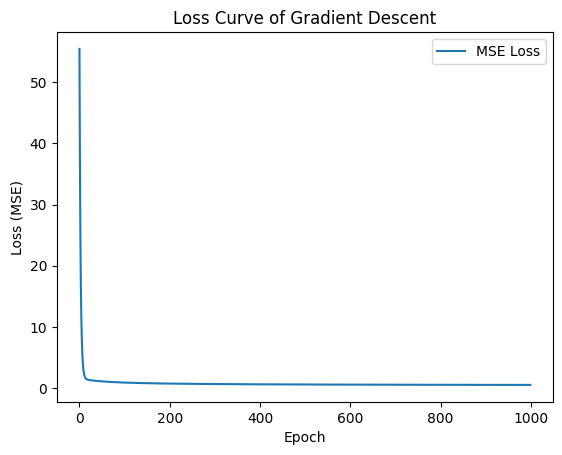

In [2]:
import matplotlib.pyplot as plt
Data = {
    'sample': ['S1','S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S12','S13','S14','S15'],
    'Drug': ['Control','DrugA','DrugB','DrugC','Control',
             'DrugA','DrugB','DrugC','Control','DrugA',
             'DrugB','DrugC','Control','DrugA','DrugB'],
    'Tissue': ['Liver','Heart','Brain','Kidney','Brain',
               'Liver','Heart','Kidney','Brain','Heart',
               'Liver','Kidney','Liver','Brain','Heart'],
    'Time': ['Day1','Day3','Day7','Day1','Day3',
             'Day7','Day1','Day3','Day7','Day1',
             'Day3','Day7','Day1','Day3','Day7'],
    'GeneA': [2.0, 1.5, 0.8, 3.2, 2.5, 1.0, 2.2, 2.9, 1.7, 3.0, 2.1, 2.8, 1.3, 2.4, 1.9],
    'GeneB': [1.5, 2.2, 0.7, 1.0, 2.5, 1.8, 0.9, 1.2, 2.0, 1.5, 1.7, 2.3, 1.4, 2.1, 1.6],
    'Phenotype': [5, 7, 6, 9, 8, 4, 7, 10, 6, 11, 7, 9, 5, 8, 6]
}
df = pd.DataFrame(Data)
df_encoded = pd.get_dummies(df,columns =['Drug', 'Tissue','Time'], drop_first=False)
X = df_encoded[['GeneA', 'GeneB','Drug_Control','Drug_DrugA','Drug_DrugB','Drug_DrugC',
                'Tissue_Brain','Tissue_Heart','Tissue_Kidney',
                'Time_Day1','Time_Day3','Time_Day7']].values.astype(float)
X = np.hstack((np.ones((X.shape[0],1)),X))
y = df_encoded['Phenotype'].values.astype(float).reshape(-1,1)
w = np.zeros((X.shape[1],1))    # 初始化权重为零    
lr = 0.01  # 学习率
num_epochs = 1000  # 迭代次数   


# ===== 梯度下降 + 记录 loss =====
losses = []
for epoch in range(num_epochs):
    y_pred = X.dot(w)  # 预测值
    error = y_pred - y  # 误差
    gradient = (2/X.shape[0]) * (X.T.dot(error))   # 计算梯度
    w -= lr * gradient  # 更新权重  

    loss = np.mean(error**2)
    if (epoch+1) % 200 == 0:
        print(f"Epoch {epoch+1}, Loss={loss:.4f}")
    losses.append(loss)

# ===== 可视化 Loss 曲线 =====
plt.plot(range(num_epochs), losses, label="MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Loss Curve of Gradient Descent")
plt.legend()
plt.show()

In [3]:
Data = {
    'sample': [f"S{i}" for i in range(1,21)],
    'Condition': ['Control','Knockdown','TreatmentA','TreatmentB']*5,
    'Tissue': ['Liver','Heart','Brain','Liver','Heart']*4,
    'GeneA': np.random.uniform(0.5, 3.5, 20),
    'GeneB': np.random.uniform(0.5, 3.5, 20),
    'Phenotype': np.random.randint(4, 12, 20)
}

df = pd.DataFrame(Data)
df_encoded = pd.get_dummies(df,columns =['Condition', 'Tissue'], drop_first=False)
X = df_encoded[['GeneA', 'GeneB','Condition_Control','Condition_Knockdown',
                'Condition_TreatmentA','Condition_TreatmentB',
                'Tissue_Brain','Tissue_Heart']].values.astype(float)

# 对 GeneA 和 GeneB 做 Z-score 标准化
df_encoded['GeneA'] = (df_encoded['GeneA'] - df_encoded['GeneA'].mean()) / df_encoded['GeneA'].std()
df_encoded['GeneB'] = (df_encoded['GeneB'] - df_encoded['GeneB'].mean()) / df_encoded['GeneB'].std()

X = df_encoded[['GeneA','GeneB',
                'Condition_Control','Condition_Knockdown',
                'Condition_TreatmentA','Condition_TreatmentB',
                'Tissue_Brain','Tissue_Heart']].values.astype(float)

# 添加截距项
X = np.hstack((np.ones((X.shape[0],1)), X))
y = df_encoded['Phenotype'].values.astype(float).reshape(-1,1)
w = np.zeros((X.shape[1],1))    # 初始化权重为零
lr = 0.01  # 学习率
num_epochs = 1000  # 迭代次数
for epoch in range(num_epochs):
    y_pred = X.dot(w)  # 预测值
    error = y_pred - y  # 误差
    gradient = (2/X.shape[0]) * (X.T.dot(error))   # 计算梯度
    w -= lr * gradient  # 更新权重
print("训练完成后的权重：", w)


import matplotlib.pyplot as plt
# ===== 梯度下降 + 记录 loss =====  
losses = []
for epoch in range(num_epochs):
    y_pred = X.dot(w)  # 预测值
    error = y_pred - y  # 误差
    gradient = (2/X.shape[0]) * (X.T.dot(error))   # 计算梯度
    w -= lr * gradient  # 更新权重  

    loss = np.mean(error**2)
    if (epoch+1) % 200 == 0:
        print(f"Epoch {epoch+1}, Loss={loss:.4f}")
    losses.append(loss)

训练完成后的权重： [[ 4.60384526]
 [-0.33756406]
 [ 0.7249731 ]
 [ 2.1207377 ]
 [-0.00561975]
 [ 1.72080761]
 [ 0.7679197 ]
 [ 2.70698565]
 [ 3.03724783]]
Epoch 200, Loss=2.2514
Epoch 400, Loss=2.2474
Epoch 600, Loss=2.2453
Epoch 800, Loss=2.2441
Epoch 1000, Loss=2.2434


训练完成后的权重： [[ 5.45473311]
 [-0.01191368]
 [ 0.06531132]
 [ 1.13271828]
 [ 2.68463414]
 [ 0.53847938]
 [ 1.0989013 ]
 [ 0.74248133]
 [ 0.69051508]]


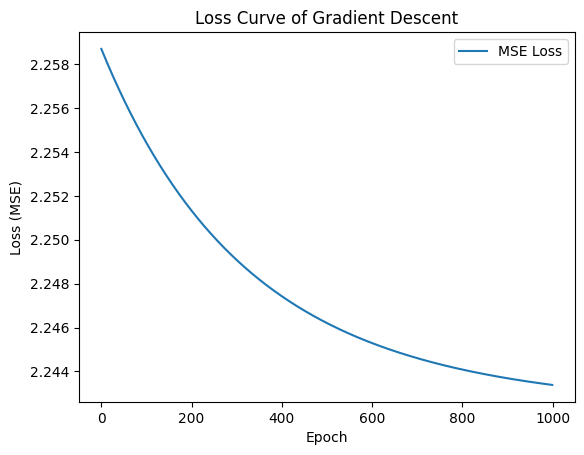

In [ ]:


Data = {
    'sample': [f"S{i}" for i in range(1,21)],
    'Condition': ['Control','Knockdown','TreatmentA','TreatmentB']*5,
    'Tissue': ['Liver','Heart','Brain','Liver','Heart']*4,
    'GeneA': np.random.uniform(0.5, 3.5, 20),
    'GeneB': np.random.uniform(0.5, 3.5, 20),
    'Phenotype': np.random.randint(4, 12, 20)
}
df = pd.DataFrame(Data)
df_encoded = pd.get_dummies(df,columns =['Condition', 'Tissue'], drop_first=False)
X = df_encoded[['GeneA', 'GeneB','Condition_Control','Condition_Knockdown',
                'Condition_TreatmentA','Condition_TreatmentB',
                'Tissue_Brain','Tissue_Heart']].values.astype(float)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[:,0:2] = scaler.fit_transform(X[:,0:2])  # 对 GeneA 和 GeneB 做 Z-score 标准化
X = np.hstack((np.ones((X.shape[0],1)), X))
y = df_encoded['Phenotype'].values.astype(float).reshape(-1,1)
w = np.zeros((X.shape[1],1))    # 初始化权重为零
lr = 0.01  # 学习率
num_epochs = 1000  # 迭代次数
losses = []   # 记录 loss

for epoch in range(num_epochs):
    y_pred = X.dot(w)  # 预测值
    error = y_pred - y  # 误差
    gradient = (2/X.shape[0]) * (X.T.dot(error))   # 计算梯度
    w -= lr * gradient  # 更新权重
print("训练完成后的权重：", w)

# ===== 可视化 Loss 曲线 =====
plt.plot(range(num_epochs), losses, label="MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")    
plt.title("Loss Curve of Gradient Descent")
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ===== 构造数据 =====
Data = {
    'sample': [f"S{i}" for i in range(1,25)],
    'Drug': ['Control','DrugA','DrugB','DrugC']*6,
    'Tissue': ['Liver','Heart','Brain']*8,
    'Time': ['Day1','Day3','Day7']*8,
    'GeneA': np.random.uniform(0.5, 3.5, 24),
    'GeneB': np.random.uniform(0.5, 3.5, 24),
    'GeneC': np.random.uniform(0.5, 3.5, 24),
    'Phenotype': np.random.randint(4, 12, 24)
}
df = pd.DataFrame(Data)
df_encoded = pd.get_dummies(df,columns =['Drug', 'Tissue','Time'], drop_first=False)
X = df_encoded[['GeneA', 'GeneB','GeneC',
                'Drug_Control','Drug_DrugA','Drug_DrugB','Drug_DrugC',
                'Tissue_Brain','Tissue_Heart','Tissue_Liver',
                'Time_Day1','Time_Day3','Time_Day7']].values.astype(float)

# 对 GeneA、GeneB 和 GeneC 做 Z-score 标准化
scaler = StandardScaler()
X[:,0:3] = scaler.fit_transform(X[:,0:3])

# ===== 添加截距项 =====
X = np.hstack((np.ones((X.shape[0],1)),X))

# ===== 标签 =====
y = df_encoded['Phenotype'].values.astype(float).reshape(-1,1)

# ===== 梯度下降 =====
w = np.zeros((X.shape[1],1))    # 初始化权重为零
lr = 0.01  # 学习率
num_epochs = 1000  # 迭代次数
losses = []   # 记录 loss
for epoch in range(num_epochs):
    y_pred = X.dot(w)  # 预测值
    error = y_pred - y  # 误差
    gradient = (2/X.shape[0]) * (X.T.dot(error))   # 计算梯度
    w -= lr * gradient  # 更新权重
    
    loss = np.mean(error**2)
    if (epoch+1) % 200 == 0:
        print(f"Epoch {epoch+1}, Loss={loss:.4f}")
    losses.append(loss)
print("训练完成后的权重：", w)

# ===== 可视化 Loss 曲线 =====
plt.plot(range(num_epochs), losses, label="MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")    
plt.title("Loss Curve of Gradient Descent")
plt.legend()
plt.show()

In [ ]:
X['GeneA'] = (df_encoded['GeneA'] - df_encoded['GeneA'].mean()) / df_encoded['GeneA'].std()
X['GeneB'] = (df_encoded['GeneB'] - df_encoded['GeneB'].mean()) / df_encoded['GeneB'].std()
X['GeneC'] = (df_encoded['GeneC'] - df_encoded['GeneC'].mean()) / df_encoded['GeneC'].std()


C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packa

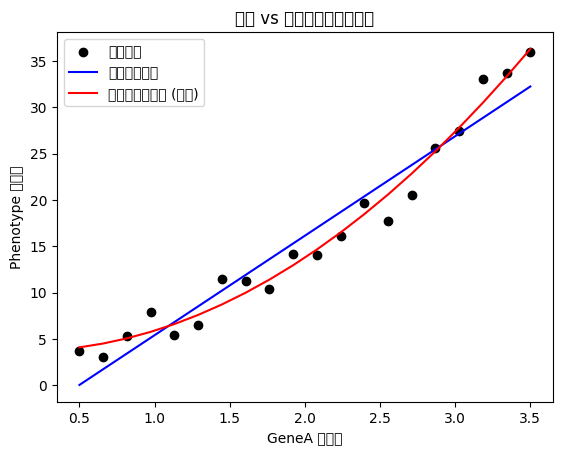

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# ===== 构造数据 =====
np.random.seed(42)
GeneA = np.linspace(0.5, 3.5, 20)
Phenotype = 2 + 3*GeneA**2 + np.random.normal(0,2,20)  # 非线性关系 + 噪声

df = pd.DataFrame({'GeneA': GeneA, 'Phenotype': Phenotype})

# ===== 线性回归 =====
lin_reg = LinearRegression()
lin_reg.fit(df[['GeneA']], df['Phenotype'])
y_lin_pred = lin_reg.predict(df[['GeneA']])

# ===== 多项式回归 (二次项) =====
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(df[['GeneA']])
poly_reg = LinearRegression()
poly_reg.fit(X_poly, df['Phenotype'])
y_poly_pred = poly_reg.predict(X_poly)

# ===== 可视化对比 =====
plt.scatter(df['GeneA'], df['Phenotype'], color='black', label="真实数据")
plt.plot(df['GeneA'], y_lin_pred, color='blue', label="线性回归拟合")
plt.plot(df['GeneA'], y_poly_pred, color='red', label="多项式回归拟合 (二次)")
plt.xlabel("GeneA 表达量")
plt.ylabel("Phenotype 表型值")
plt.title("线性 vs 多项式回归拟合曲线")
plt.legend()
plt.show()


Epoch 200, Loss=19.3750
Epoch 400, Loss=8.1088
Epoch 600, Loss=5.1325
Epoch 800, Loss=4.3245
Epoch 1000, Loss=4.0933
训练完成后的权重：
 [[ 4.3210679 ]
 [-0.24134197]
 [ 0.53921435]
 [-0.15165766]
 [ 0.41753602]
 [ 0.58065587]
 [ 1.48263403]
 [ 1.08847335]
 [ 1.74996052]
 [ 1.48263403]
 [ 1.08847335]
 [ 1.74996052]]


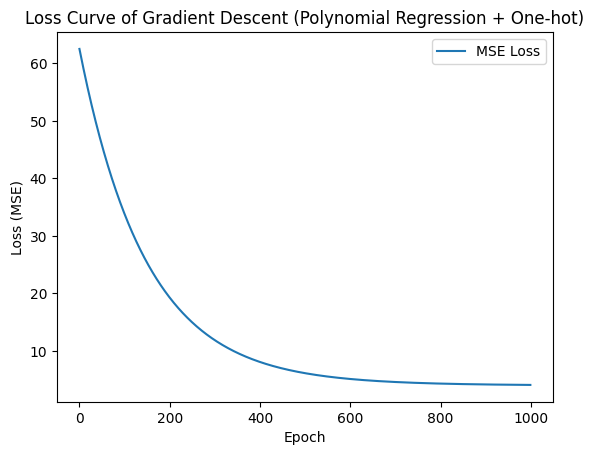

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ===== 构造数据 =====
np.random.seed(42)
Data = {
    'sample': [f"S{i}" for i in range(1,31)],
    'Drug': ['Control','DrugA','DrugB']*10,
    'Tissue': ['Liver','Heart','Brain']*10,
    'GeneA': np.random.uniform(0.5, 3.5, 30),
    'GeneB': np.random.uniform(0.5, 3.5, 30),
    'Phenotype': np.random.randint(4, 12, 30)
}
df = pd.DataFrame(Data)

# ===== One-hot 编码 =====
df_encoded = pd.get_dummies(df, columns=['Drug','Tissue'], drop_first=False)

# ===== 构造多项式特征 =====
df_encoded['GeneA^2'] = df_encoded['GeneA']**2
df_encoded['GeneB^2'] = df_encoded['GeneB']**2
df_encoded['GeneA*GeneB'] = df_encoded['GeneA'] * df_encoded['GeneB']

# ===== 提取特征矩阵 =====
X = df_encoded[['GeneA','GeneB','GeneA^2','GeneB^2','GeneA*GeneB',
                'Drug_Control','Drug_DrugA','Drug_DrugB',
                'Tissue_Liver','Tissue_Heart','Tissue_Brain']].values.astype(float)

# ===== 标准化数值特征 =====
scaler = StandardScaler()
X[:,0:5] = scaler.fit_transform(X[:,0:5])  # 前五列是数值特征

# ===== 添加截距项 =====
X = np.hstack((np.ones((X.shape[0],1)), X))

# ===== 标签 =====
y = df_encoded['Phenotype'].values.astype(float).reshape(-1,1)

# ===== 梯度下降 =====
w = np.zeros((X.shape[1],1))
lr = 0.001
num_epochs = 1000
losses = []

for epoch in range(num_epochs):
    y_pred = X.dot(w)
    error = y_pred - y
    gradient = (2/X.shape[0]) * (X.T.dot(error))
    w -= lr * gradient
    
    loss = np.mean(error**2)
    losses.append(loss)
    if (epoch+1) % 200 == 0:
        print(f"Epoch {epoch+1}, Loss={loss:.4f}")

print("训练完成后的权重：\n", w)

# ===== 可视化 Loss 曲线 =====
plt.plot(range(num_epochs), losses, label="MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Loss Curve of Gradient Descent (Polynomial Regression + One-hot)")
plt.legend()
plt.show()


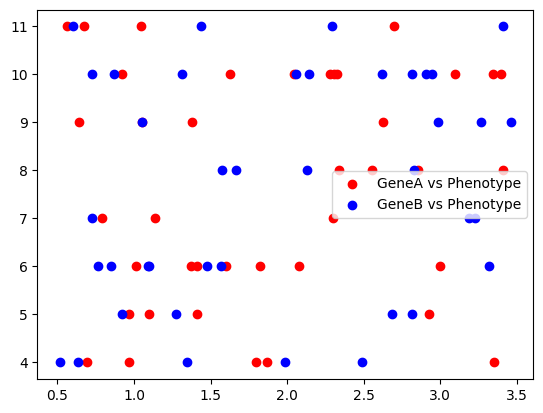

Index(['sample', 'GeneA', 'GeneB', 'Phenotype', 'GeneA_squared', 'GeneA_cubed',
       'GeneB_squared', 'GeneB_cubed', 'Drug_Control', 'Drug_DrugX',
       'Drug_DrugY', 'Tissue_Kidney', 'Tissue_Liver', 'Tissue_Lung'],
      dtype='object')
Epoch   500  loss = 4.427659
Epoch  1000  loss = 4.418297
Epoch  1500  loss = 4.414711
Epoch  2000  loss = 4.411808
Epoch  2500  loss = 4.409106
Epoch  3000  loss = 4.406488


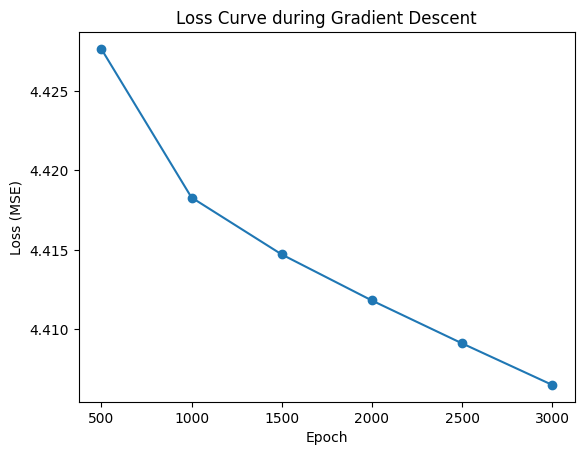

Intercept      : 4.676873
GeneA          : -0.000753
GeneB          : 0.303386
GeneA_squared  : 0.600150
GeneA_cubed    : -0.352338
GeneB_squared  : -0.040528
GeneB_cubed    : 0.251753
Drug_Control   : 1.201065
Drug_DrugX     : 1.301204
Drug_DrugY     : 2.174604
Tissue_Kidney  : 2.174604
Tissue_Liver   : 1.137519
Tissue_Lung    : 1.364750


C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packa

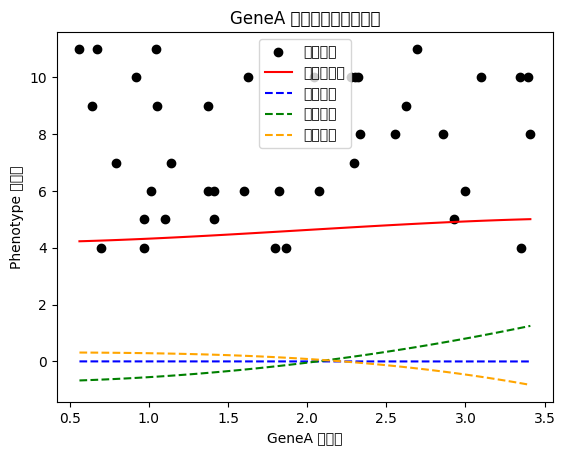

In [7]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler 

# ===== 构造数据 ===== 
np.random.seed(42) 
Data = { 
    'sample': [f"S{i}" for i in range(1, 41)], 
    'Drug': ['Control', 'DrugX', 'DrugY', 'DrugX'] * 10,  # 4种循环 
    'Tissue': ['Liver', 'Lung', 'Kidney', 'Liver'] * 10, 
    'GeneA': np.random.uniform(0.5, 3.5, 40), 
    'GeneB': np.random.uniform(0.5, 3.5, 40), 
    'Phenotype': np.random.randint(4, 12, 40) 
} 

df = pd.DataFrame(Data) 

# 用散点图判断是否需要非线性拟合 
plt.scatter(df['GeneA'], df['Phenotype'], color='red', label='GeneA vs Phenotype') 
plt.scatter(df['GeneB'], df['Phenotype'], color='blue', label='GeneB vs Phenotype') 
plt.legend() 
plt.show() 

# 构造多项式特征 
df['GeneA_squared'] = df['GeneA']**2 
df['GeneA_cubed'] = df['GeneA']**3 
df['GeneB_squared'] = df['GeneB']**2 
df['GeneB_cubed'] = df['GeneB']**3 

df_encoded = pd.get_dummies(df, columns=['Drug','Tissue'], drop_first=False) 
print(df_encoded.columns) 

# ==== 提取特征矩阵 X 和向量 y ======== 
X = df_encoded[['GeneA','GeneB','GeneA_squared','GeneA_cubed',
                'GeneB_squared','GeneB_cubed', 
                'Drug_Control','Drug_DrugX','Drug_DrugY',
                'Tissue_Kidney','Tissue_Liver','Tissue_Lung']].values.astype(float) 

y = df_encoded['Phenotype'].values.astype(float).reshape(-1,1) 

# ====== X 加截距 ======= 
X = np.hstack([np.ones((X.shape[0],1)), X]) 

# ===== 标准化 ========= 
scaler = StandardScaler() 
X[:,1:7] = scaler.fit_transform(X[:,1:7])   # 注意这里是 1:7，不包括截距列

# ======== 梯度下降 ========== 
w = np.zeros((X.shape[1],1)) 
lr = 0.01 
epochs = 3000 
n_samples = X.shape[0] 
losses = [] 

for epoch in range(epochs): 
    y_hat = X.dot(w)              # 预测值 
    error = y_hat - y             # 残差 
    grad = (2.0 / n_samples) * (X.T.dot(error))  # 梯度 
    w -= lr * grad                # 更新参数 
    
    if (epoch + 1) % 500 == 0: 
        loss = np.mean(error ** 2) 
        losses.append(loss) 
        print(f"Epoch {epoch+1:5d}  loss = {loss:.6f}") 
        
# ========= loss曲线可视化 ======== 
plt.plot(range(500, epochs+1, 500), losses, marker='o') 
plt.xlabel("Epoch") 
plt.ylabel("Loss (MSE)") 
plt.title("Loss Curve during Gradient Descent") 
plt.show() 

# ======= 打印每个因素的权重 =========== 
feature_names = ["Intercept",'GeneA','GeneB','GeneA_squared',
                 'GeneA_cubed','GeneB_squared','GeneB_cubed',
                 'Drug_Control','Drug_DrugX','Drug_DrugY',
                 'Tissue_Kidney','Tissue_Liver','Tissue_Lung'] 

for name, coef in zip(feature_names, w.flatten()): 
    print(f"{name:15s}: {coef:.6f}") 

# ===== 构造绘图用的特征矩阵 ===== 
GeneA_range = np.linspace(df['GeneA'].min(), df['GeneA'].max(), 100) 
GeneB_mean = df['GeneB'].mean() 

GeneA_features = np.column_stack([ 
    GeneA_range, 
    np.full_like(GeneA_range, GeneB_mean), 
    GeneA_range**2, 
    GeneA_range**3, 
    np.full_like(GeneA_range, GeneB_mean**2), 
    np.full_like(GeneA_range, GeneB_mean**3) 
]) 

# 标准化数值特征 
GeneA_features_scaled = scaler.transform(GeneA_features) 

# 拼接成完整的 X_plot（截距 + 数值特征 + 类别变量置零） 
X_plot = np.hstack([ 
    np.ones((GeneA_range.shape[0],1)),   # 截距 
    GeneA_features_scaled,               # 标准化后的数值特征 
    np.zeros((GeneA_range.shape[0],6))   # 类别变量置零 
]) 

# 分别计算不同阶的贡献 
y_linear = w[1]*GeneA_features_scaled[:,0]   # GeneA 一阶 
y_square = w[3]*GeneA_features_scaled[:,2]   # GeneA² 
y_cube   = w[4]*GeneA_features_scaled[:,3]   # GeneA³ 

# 总拟合 
y_total = X_plot.dot(w) 

# 绘图 
plt.scatter(df['GeneA'], df['Phenotype'], color='black', label='真实数据') 
plt.plot(GeneA_range, y_total, color='red', label='总拟合曲线') 
plt.plot(GeneA_range, y_linear, color='blue', linestyle='--', label='一阶贡献') 
plt.plot(GeneA_range, y_square, color='green', linestyle='--', label='二阶贡献') 
plt.plot(GeneA_range, y_cube, color='orange', linestyle='--', label='三阶贡献') 
plt.xlabel("GeneA 表达量") 
plt.ylabel("Phenotype 表型值") 
plt.title("GeneA 不同阶项的拟合贡献") 
plt.legend() 
plt.show() 


  sample Tissue     GeneX     GeneY  DrugResponse
0     S1  Liver  0.597937  3.684193            24
1     S2  Heart  1.108673  1.264316            13
2     S3  Liver  1.039288  1.770864            13
3     S4  Liver  0.769803  3.492405            24
4     S5  Brain  3.614530  2.989871            26


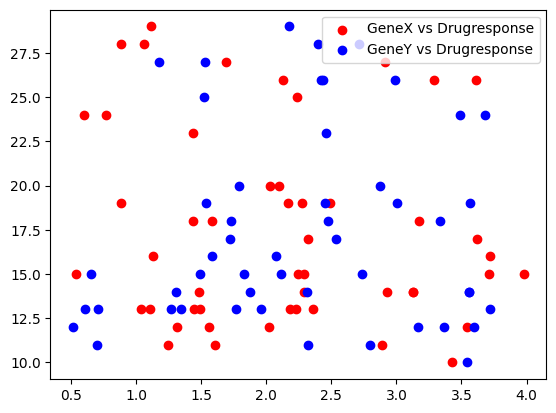

Index(['sample', 'GeneX', 'GeneY', 'DrugResponse', 'GeneX_squared',
       'GeneX_cubed', 'GeneY_squared', 'GeneY_cubed', 'Tissue_Brain',
       'Tissue_Heart', 'Tissue_Liver'],
      dtype='object')


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


# 固定随机种子，保证结果可复现
np.random.seed(123)

# ===== 构造数据 =====
Data = {
    'sample': [f"S{i}" for i in range(1, 51)],   # 50 个样本
    'Tissue': np.random.choice(['Brain', 'Heart', 'Liver'], size=50),  # 随机组织来源
    'GeneX': np.random.uniform(0.5, 4.0, 50),    # 基因 X 表达量
    'GeneY': np.random.uniform(0.5, 4.0, 50),    # 基因 Y 表达量
    'DrugResponse': np.random.randint(10, 30, 50) # 药物反应值
}

df = pd.DataFrame(Data)

# 查看前几行
print(df.head())


# ========== 用散点图判断是否需要非线性拟合 ======

plt.scatter(df['GeneX'], df['DrugResponse'], color='red', label='GeneX vs Drugresponse') 
plt.scatter(df['GeneY'], df['DrugResponse'], color='blue', label='GeneY vs Drugresponse') 
plt.legend() 
plt.show()


# ===== 构造多项式特征 =====
df['GeneX_squared'] = df['GeneX']**2
df['GeneX_cubed']   = df['GeneX']**3
df['GeneY_squared'] = df['GeneY']**2
df['GeneY_cubed']   = df['GeneY']**3

# ===== One-hot 编码组织来源 =====
df_encoded = pd.get_dummies(df, columns=['Tissue'], drop_first=False)

# 查看编码后的列
print(df_encoded.columns)


# ========= 提取特征矩阵集X和特征向量y ========
